# MINI PROJECT: BUILDING A ROBO-ADVISOR
## Supervisor: Professor Steve Taylor
## Date: 11th November 2022 
## Stevens Institute of Technology - Fall 2022

Both Betterment and Wealthfront discuss the utilization of the Modern Portfolio Theory (MPT). It is one of the widely accepted frameworks for managing diversified portfolios. Wealthfront does not go into too much detail about their utilization of the MPT, they simply mention that it is used in their investment methodology to “construct asset allocations that maximize the expected net-of-fee, after-tax real return for each level of portfolio risk.” Betterment, however, explains that their portfolio construction goes beyond MPT by adding additional estimates and evaluation factors such as estimates of forward-looking returns, covariance, estimation error and other specific factors in the portfolio. It is essentially a reconstructed version of MPT with more factors accounted.

When looking into the chosen asset classes of each respective robo-advisor it is interesting to note that both Betterment and Wealthfront selected emerging market equities, developed market equities such as the US or international market and bonds. Betterment, however, does exclude commodities while Wealthfront does not. Betterment says that asset classes such as private equities, commodities and natural resources “may not show sensitivity to total portfolio returns.” Wealthfront, however, argues that investing in commodities “provides inflation protection and diversification… also relatively tax efficient due to the favorable tax treatment on long-term capital gains and stock dividends.”

Wealthfront also mentions that to construct estimates of each asset class’s expected return they use the Black-Litterman model to blend returns from the Capital Asset Pricing Model (CAPM) with long term expectations obtained from the Wealthfront Capital Markets Model.  Betterment also mentions using the CAPM to compute forward-looking returns and the use of the Black-Litterman Model to tilt the portfolios in order to gain higher returns from value and size. They also both mention the use of Monte Carlo simulations to predict alternative market scenarios.

A big limitation to the Betterment strategy, I believe, is not giving investors the option or flexibility to invest in commodities. Especially in the recent market “pullback” there could be a growing interest in commodity ETFs. As mentioned by Wealthfront, investing in commodities, especially those like precious metals can provide inflation protection and be tax efficient. That is why including commodities in the Betterment core portfolio may be a great addition and may bring additional interest to the platform.


## Asset Selection:

Our method for asset selection is based on Wealthfront cost effective methodology.
The program uses ETF's which provide cost benefits compared to the alternative of investing in whole stocks or mutual funds. With this in mind our asset selection criteria are :

1. We select the lowest ETF based on expense ratio , the program is optimised to get the current expense rates from yahoo finance based on a web scrapper.

2. Next is volume, the higher the liquidity of the ETF the more efficeint sales and purchases can be made. Yahoo finance provides the current average trading volume, a good indicator of the ETF's liquidity. The web scrapper provides this information accurately.

2. Tracking error of the ETF. The higher the variance from its selected benchmark (tracking error), the less appropriate an ETF is to represent its asset class. Preferably, the lower the rate the better.


The following are our benchmarks and etf's were selected.

US STOCK we will use S&P500("^GSPC") as the market index the following ETFs are used:
1. SPDR S&P 500 ETF Trust (SPY)
2. Vanguard 500 Index Fund (VOO)
3. iShares Core S&P 500 ETF (IVV)

US Treasury we will use Fidelity SAI U.S. Treasury Bond Index Fund (FUTBX) as the market index the following ETFs are used:
1. iShares Treasury Floating Rate Bond ETF (TFLO)
2. WisdomTree Floating Rate Treasury Fund (USFR)
3. Franklin U.S. Treasury Bond ETF (FLGV)

US Corporate Bonds we will use Fidelity U.S. Bond Index Fund (FXNAX) as the market index the following ETFs are used:
1. Schwab 5-10 Year Corporate Bond ETF (SCHI)
2. Goldman Sachs Access Investment Grade Corporate Bond ETF (GIGB)
3. SPDR Portfolio Corporate Bond ETF (SPBO)

US Real Estate we will use Vanguard Real Estate Index Fund (VGSIX) as the market index the following ETFs are used:
1. Vanguard Real Estate Index Fund (VNQ)
2. iShares Core U.S. REIT ETF (USRT)
3. Schwab U.S. REIT ETF (SCHH)


## Algorithm for Asset Selection

In [5]:
## Loading Packages

import pandas as pd
import numpy as np
import requests, lxml
from lxml import html
from datetime import datetime
import time
from bs4 import BeautifulSoup
import math 
import statistics
import calendar

pd.core.common.is_list_like = pd.api.types.is_list_like
import numpy as np
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from numpy.linalg import inv
from cvxopt import matrix, solvers 
from numpy import c_
import datetime as dt
from scipy.optimize import minimize 


In [3]:
## Define url for scraping 

def assetdetails(etf,bench,start,end):
    '''
    This function scrapes yahoo finance for the expense ratio, volume , pulls 
    out the ETF's adjusted prices and computes the tracking error. 
    
    '''
    
    # type the etf as string
    etf = etf
    #join the url with the string
    items = ("https://finance.yahoo.com/quote/",etf,"/profile?p=",etf)
    url = "".join(items)
    
    
    ## Pull the data from the website using beautiful soup package
    r = requests.get(url,headers={"User-Agent":"Mozilla/5.0"})
    soup = BeautifulSoup(r.text,'html.parser')
    
    #------------
    # locate the data n pull out the annualized rate
    soup2= soup.find_all('div',{"class":"Bdbw(1px) Bdbc($seperatorColor) Bdbs(s) H(25px) Pt(10px)"})
    a = soup2[6].find_all("span",{"class":"W(20%) D(b) Fl(start) Ta(e)"})
    a = a[0].text
    a = float(a.split("%")[0])
    
    #--------------
    
    ## Pull data for volume
    #join the url with the string
    items = ("https://finance.yahoo.com/quote/",etf,"?p=",etf)
    url = "".join(items)
    
    ## Pull the data from the website using beautiful soup package
    r = requests.get(url,headers={"User-Agent":"Mozilla/5.0"})
    soup = BeautifulSoup(r.text,'html.parser')
    # locate the data n pull out the avg volume
    soup2= soup.find('table',class_="W(100%)")
    s3 = soup2.find_all('td',class_="Ta(end) Fw(600) Lh(14px)")
    s3 = s3[7].text
    s3 = float(s3.replace(",",""))
    
    #---------------
    ## Calculating the Tracking Error over n years,  download data 
    ETF = web.DataReader(etf, 'yahoo', start, end)
    BENCH = web.DataReader(bench, 'yahoo', start, end)
    #join the Adj Closing Prices data togehter 
    lsttojoin = [ETF['Adj Close'],BENCH['Adj Close']] 
    prcdf = pd.concat(lsttojoin,axis=1)

    #Rename the columns
    prcdf.columns = [etf,bench]
    # Sort them by dates
    prcdf = prcdf.sort_index() 
    #calc returns
    rtndf = prcdf.pct_change(1).dropna()
    #calc means
    rtmean = rtndf.mean()*252
    #Tracking Error
    irvol = np.std(rtndf.iloc[:,0] - rtndf.iloc[:,1])*np.sqrt(252)
    #Information Ratio
    #infor = (rtmean[0] - rtmean[1])/ irvol 
    
    

    return({etf:[a,s3,irvol]})



# Code to select the asset


def asset_selec(tickers):
    for i in tickers[0:3]:
        f_dict = assetdetails(i,tickers[3],start,end)
        a = f_dict.keys()
        fans[list(a)[0]] = list(f_dict.values())[0]
        
    #Logging of Keys
    log_keys = {}
    
    #Min Expense Ratio:
    a = fans.T.sort_values(by=fans.T.columns[0])
    log_keys[a.index[0]] = 1
    
    #Min Tracking Error :
    a = fans.T.sort_values(by=fans.T.columns[2])
    if a.index[2] in log_keys.keys() :
        log_keys[a.index[0]] = 2
    else:
        log_keys[a.index[0]] = 1
        
    #Max Volume :
    a = fans.T.sort_values(by=fans.T.columns[1])
    
    if a.index[2] in log_keys.keys() :
        log_keys[a.index[2]] = log_keys.get(a.index[2]) + 1
    else:
        log_keys[a.index[2]] = 1
    

    
    #Deciding based on the best of 2 or 3 if 1 just choose the lowest Expense Ratio
    if max(log_keys.values()) > 1 :
        chosen_key = max(log_keys , key = log_keys.get )
    else : 
        a = fans.T.sort_values(by=fans.T.columns[0])
        chosen_key = a.index[0]
        
    print(fans.T)
    print(log_keys)
    print(chosen_key)
    return(chosen_key)



#### US Stock Selection:

In [6]:
# List of selected ETF's
etf_selected = []

# Define the start and end dates of etf n index prices
start = dt.datetime(2021, 8, 31)
end = dt.datetime(2022, 8, 31)

# List the ETFS the last string should be the index
fans = pd.DataFrame()
#US Stocks
tickers = ['SPY','IVV','VOO','^GSPC']
etf_selected.append(asset_selec(tickers))

        0           1         2
SPY  0.09  87949973.0  0.006475
IVV  0.03   5011225.0  0.006932
VOO  0.03   4616765.0  0.007368
{'IVV': 1, 'SPY': 2}
SPY


#### US Treasury Selection:

In [7]:
# List the ETFS the last string should be the index
fans = pd.DataFrame()
#US Treasury
tickers = ['TFLO','USFR','FLGV','FUTBX']
etf_selected.append(asset_selec(tickers))

         0          1         2
TFLO  0.15  1172538.0  0.063532
USFR  0.15  3481146.0  0.063434
FLGV  0.09   107734.0  0.022842
{'FLGV': 1, 'USFR': 1}
FLGV


#### US Corporate Bonds:

In [8]:
# List the ETFS the last string should be the index
fans = pd.DataFrame()
#US Corporate Bonds
tickers = ['SCHI','GIGB','SPBO','FXNAX']
etf_selected.append(asset_selec(tickers))

         0         1         2
SCHI  0.03   89622.0  0.031486
GIGB  0.14   64406.0  0.041476
SPBO  0.03  194535.0  0.041625
{'SCHI': 1, 'SPBO': 1}
SCHI


#### US Real Estate

In [9]:
# List the ETFS the last string should be the index
fans = pd.DataFrame()
#US Real Estate
tickers = ['VNQ','USRT','SCHH','VGSIX']
etf_selected.append(asset_selec(tickers))

         0          1         2
VNQ   0.12  5444068.0  0.008694
USRT  0.08   253635.0  0.029688
SCHH  0.07  2674356.0  0.014775
{'SCHH': 1, 'VNQ': 2}
VNQ


#### The ETF's Selected are : 

In [10]:
etf_selected

['SPY', 'FLGV', 'SCHI', 'VNQ']

## Asset Allocation:

Calculated the annual returns , covariance matrix and defining the functions for the mean variance portfolio.

In [13]:
# Define the start and end dates of stock prices
start = dt.datetime(2021, 8, 31)
end = dt.datetime(2022, 8, 31)

# download data 
A1 = web.DataReader(etf_selected[0], 'yahoo', start, end)
A2 = web.DataReader(etf_selected[1], 'yahoo', start, end)
A3 = web.DataReader(etf_selected[2], 'yahoo', start, end)
A4 = web.DataReader(etf_selected[3], 'yahoo', start, end)


#join the Adj Closing Prices data togehter 
lsttojoin = [A1['Adj Close'],A2['Adj Close'],A3['Adj Close'],A4['Adj Close']] 
prcdf = pd.concat(lsttojoin,axis=1)

#Rename the columns
prcdf.columns = etf_selected

# Sort them by dates
prcdf = prcdf.sort_index() 
 
#Calculate the returns  and remove the first column

rtndf = prcdf.pct_change(1).dropna()

rtndf = rtndf

rtmean = rtndf.mean()

covmat = rtndf.cov()



# Functions to calculate the mean , variance , minimise obj
def portrtn(weights):
    '''
     This function calculates the annual return on the portfolio
    '''
    
    return np.sum(rtmean*weights)*252

def portvar(weights):
    '''
     This function calculates the annual volatiliy on the portfolio
     based on covariance matrix and estimated weights 
    '''
    return np.sqrt(np.dot(weights.T, np.dot(covmat*252, weights)))
    
def mark_obj(weights,lam):
    '''
     This function is to optimize between return , and variance of the portfolio.
     The function is used in the minimize function to estimate the weights for the 
     optimal portfolio.
    '''
    
    return portvar(weights)**2 - lam*portrtn(weights)






The function below set the minimize function and the constraints for the function.
We constraint our asset weights to be within bounds (0,1) and a maximum weight of 50%
Further improvement can be done here by setting utilization function to estimate the risk appetite for an investor. This will help set the maximum weights for an asset. 

Further , a minimum return target can be set as a benchmark for the portfolio in optimizing for weights. Currently, the function computes weights to give minimum volatility.

In [14]:
# Set the constraints
# 1. wieghts should sum to 1

constraints = ({'type' : 'eq', 'fun': lambda x: np.sum(x) -1})
# 
# 2. wieghts should be between 0 and 1
bounds = tuple((0,0.5) for x in range(4))


# We put constraint on the the sector and the maximum to be invested 

# Further put on constrain on the minimum return we would like and optmise for minimum volatility 

# Let set a range of risk aversion parameters 

lams = np.linspace(-0.1,0.1,50)
fansrtn = []
fansrisk = []
dict_fin = pd.DataFrame()
dict_weights = {}

for i in lams:
    
    '''
     This loop runs through the risk aversion parameters , 
     and then using the minimize function optimizes the required weights
    '''

    lam = i
    #Initial random values for optimizer
    weights = np.random.dirichlet(np.ones(4), size=1)
    weights = weights[0]

    # Create a function with the risk aversion parameter estimated
    optfun = lambda x :mark_obj(x,lam)
    
    # This is the minimize function
    optimal_variance= minimize(optfun,
                                   weights,
                                   method = 'SLSQP',
                                   bounds = bounds,
                                   constraints = constraints)
    
    # Pulls out the optimal weights and compute the return and risk 
    fansw = optimal_variance['x']
    fansrtn.append(portrtn(fansw))
    fansrisk.append(portvar(fansw))
    a = pd.Series(fansw)
    dict_fin = pd.concat([dict_fin,a],axis = 1)


#Rename the columns and index
dict_fin.columns = lams
dict_fin.index = etf_selected 

dict_fin

,-0.100000,-0.095918,-0.091837,-0.087755,-0.083673,-0.079592,-0.075510,-0.071429,-0.067347,-0.063265,...,0.063265,0.067347,0.071429,0.075510,0.079592,0.083673,0.087755,0.091837,0.095918,0.100000
SPY,1.590745e-02,0.016093,0.013378,0.009021,0.016113,0.016834,1.701933e-02,1.945953e-02,1.738995e-02,1.756659e-02,...,0.091347,0.09471,0.099958,0.102673,0.101664,1.075928e-01,0.110792,0.102711,0.116056,1.189217e-01
FLGV,4.840926e-01,0.483907,0.486622,0.490979,0.483887,0.483166,4.829807e-01,4.805405e-01,4.826100e-01,4.824334e-01,...,0.500000,0.50000,0.500000,0.500000,0.500000,5.000000e-01,0.500000,0.500000,0.500000,5.000000e-01
SCHI,5.000000e-01,0.500000,0.500000,0.500000,0.500000,0.500000,5.000000e-01,5.000000e-01,5.000000e-01,5.000000e-01,...,0.408653,0.40529,0.400042,0.397327,0.398336,3.924072e-01,0.389208,0.397289,0.383944,3.810783e-01
VNQ,3.903128e-18,0.000000,0.000000,0.000000,0.000000,0.000000,3.122502e-17,1.734723e-18,2.125036e-17,2.276825e-17,...,0.000000,0.00000,0.000000,0.000000,0.000000,6.938894e-18,0.000000,0.000000,0.000000,2.081668e-17


In [34]:
#find the optimal portfolio based on minimum risk 
tf = pd.DataFrame({'Return':fansrtn,'Risk':fansrisk})
tf = tf.sort_values('Risk')
tf = tf.iloc[0,:]
print("The optimal portfolio with minimum risk on the efficient" + 
      "curve has an annual return of :"
      + str(tf[0]) + "and volatility of: "+ str(tf[1]))

The optimal portfolio with minimum risk on the efficientcurve has an annual return of :-0.12293911275430952and volatility of: 0.06106995360487835


From a range of 50 steps between the risk aversion parameter (-1,1), as the parameter increases from -1 to 1 the volatility decreases till it reaches a peak where the volatility of the portfolio is minimum and rises as the the parameter rises to 1. At parameter = 1 the return is highest and the volatility is highest.

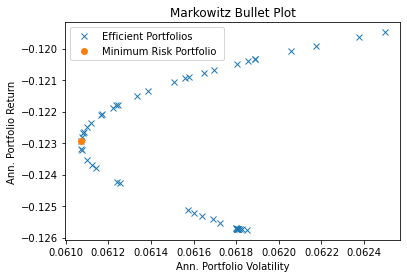

In [36]:
# Below is the plot of the efficient frontier
plt.figure()
plt.plot(fansrisk,fansrtn,'x',label = "Efficient Portfolios")
plt.plot(tf[1],tf[0],'o',label = "Minimum Risk Portfolio ")
plt.xlabel('Ann. Portfolio Volatility')
plt.ylabel('Ann. Portfolio Return')
plt.title('Markowitz Bullet Plot')
plt.legend(loc="upper left")

# put on a mark on the optimal portfolio based on variance

plt.show()

## Rebalancing and Tax-Loss Harvesting:

Ideal automatic rebalancing is a dilemma that most robo-advisors seem to face, and a big reason why many choose to stay away from robo-advisors. The idea stems from the fact that asset allocation is not designed to be fixed. It should be constantly changing and shifting along with an investor’s risk tolerance and timeline. Therefore, rebalancing is a huge part in managing a portfolio. Robo-advisors, however, tend to change balances too frequently which can be contradictory for investors who wish to maintain a buy-and-hold approach.

This frequent rebalancing is also said to increase potential for returns to overwhelm and therefore make the portfolio performance average. The other thing to consider, is that automatic balance changes can get expensive since rebalancing can cause transaction fees or taxable events to occur. It also makes the overall robo-advisor process less customizable. Most robo-advisors are often based on an investors risk tolerance score, but often do not account for other factors such as an investor’s other assets, investments, and overall financial goals. For investors who do not have all their assets centralized in one robo-advisor platform, this can be a serious issue. 

The automatic rebalancing for these investors can overwhelm the investments in one sector and therefore limit the diversification created amongst all assets in an investor’s portfolio. This is a very important thing to consider and a major drawback in most robo-advisors used today. Tax-loss harvesting is the offset of investment gains, and subsequently capital gains tax by selling under-performing investments at a loss. In the case of a taxable investment account, tax-loss harvesting can be of advantage to the investor’s portfolio. We can use the multiple securities we selected to implement tax-loss harvesting by programming a feature in our robo-advisor to automatically sell securities in a portfolio that underperform to purposely incur losses and offset capital gain or taxable income. It is important to consider in our implantation, however, that robo-advisors can cause tax inefficiency if the wash-sale rule is violated.

The rule specifies that no purchases of the or substantially identical investment can be made within 30 days prior or post sale. Robo-advisors can violate this rule automatically if they do not account for an investor harvesting losses in other accounts.

## Extensions:

In building our own robo-advisor there are many approaches that would be beneficial to mimic from Wealthfront and Betterment. For our portfolio strategy, we would similarly use developed market equities, bonds and emerging market equities. We would also lean towards the Wealthfront strategy of using private equities, commodities, and natural resources as additional asset classes. 

Our robo-advisor would be built on customizability, and we would like to offer our users as much freedom to pick and choose their asset classes as needed. To stand out from our major competitors, we would also implement the ability to import external asset information into our robo-advisor as well.

Currently, this seems to be a major drawback in most robo-advisors. We understand, of course, that we may run into compliance issues and difficulty in the constant updates of other dynamic assets changing in values, however, even a general understanding of an investor’s bigger investment picture can help our robo-advisor make better investment decisions that can cater to our specific users.
We believe that this is probably one of the major reasons investors may choose to use a financial advisor over a robo-advisor. The implantation of this “big picture approach” can help our users benefit maximally from both tax-loss harvesting and automatic rebalancing to best optimize the investor’s portfolio.